# Link Prediction Evaluation

Evaluate model predictions against ground truth for binary link prediction task.

In [57]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


## 1. Load Predictions

Load predictions from training output directory.

In [58]:
# Path to predictions file
predictions_path = Path(r"predictions_best.json")

# Load predictions
with open(predictions_path, 'r', encoding='utf-8') as f:
    predictions = json.load(f)

print(f"✓ Loaded {len(predictions):,} predictions")
print(f"  File: {predictions_path.name}")

# Show examples
print("\nExample predictions:")
for i in range(min(5, len(predictions))):
    pred = predictions[i]
    print(f"\n  [{i}] Node ID: {pred['node_id']}")
    print(f"      Prediction: {pred['prediction'][:50]}")
    print(f"      Ground truth: {pred['ground_truth']}")

✓ Loaded 2,112 predictions
  File: predictions_best.json

Example predictions:

  [0] Node ID: 9
      Prediction: assistant

yes
      Ground truth: yes

  [1] Node ID: 2650
      Prediction: assistant

yes
      Ground truth: no

  [2] Node ID: 1595
      Prediction: assistant

yes
      Ground truth: yes

  [3] Node ID: 321
      Prediction: assistant

yes
      Ground truth: yes

  [4] Node ID: 1118
      Prediction: assistant

no
      Ground truth: yes


## 2. Parse and Clean Predictions

Extract yes/no answers from model outputs (handle various formats).

In [ ]:
def parse_prediction(pred_text):
    """
    Parse prediction text to extract yes/no answer.
    Handles various formats from LLM output.
    """
    pred_lower = pred_text.lower().strip()
    
    # Remove common prefixes
    pred_lower = pred_lower.replace('assistant', '').strip()
    pred_lower = pred_lower.replace('\n', '').strip()
    
    # Check for yes/no
    if 'yes' in pred_lower and 'no' not in pred_lower:
        return 'yes'
    elif 'no' in pred_lower and 'yes' not in pred_lower:
        return 'no'
    elif pred_lower.startswith('yes'):
        return 'yes'
    elif pred_lower.startswith('no'):
        return 'no'
    else:
        return None

# Parse all predictions
y_true = []
y_pred = []
invalid_count = 0

for pred in predictions:
    ground_truth = pred['ground_truth'].lower().strip()
    parsed_pred = parse_prediction(pred['prediction'])

    y_true.append(ground_truth)
    y_pred.append(parsed_pred)
    
    if parsed_pred is None:
        invalid_count += 1

print(f"✓ Parsed predictions:")
print(f"  Ambiguous: {invalid_count:,} ({invalid_count/len(predictions)*100:.2f}%)")

# Convert to binary (1=yes, 0=no)
y_true_binary = np.array([1 if y == 'yes' else 0 for y in y_true])
y_pred_binary = np.array([1 if y == 'yes' else 0 for y in y_pred])

print(f"\n✓ Binary labels created:")
print(f"  Positive (yes) in ground truth: {y_true_binary.sum():,} ({y_true_binary.mean()*100:.2f}%)")
print(f"  Positive (yes) in predictions: {y_pred_binary.sum():,} ({y_pred_binary.mean()*100:.2f}%)")

✓ Parsed predictions:
  Ambiguous: 15 (0.71%)

✓ Binary labels created:
  Positive (yes) in ground truth: 1,056 (50.00%)
  Positive (yes) in predictions: 1,583 (74.95%)


## 3. Compute Classification Metrics

Calculate standard metrics: accuracy, precision, recall, F1-score.

In [60]:
# Compute metrics
accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

# Additional metrics
try:
    # AUC only works if both classes are present
    if len(np.unique(y_pred_binary)) > 1:
        auc_score = roc_auc_score(y_true_binary, y_pred_binary)
        avg_precision = average_precision_score(y_true_binary, y_pred_binary)
    else:
        auc_score = None
        avg_precision = None
except:
    auc_score = None
    avg_precision = None

# Print results
print("="*70)
print(" "*20 + "CLASSIFICATION METRICS")
print("="*70)
print(f"\n✓ Overall Performance:")
print(f"  Accuracy:       {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision:      {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:         {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:       {f1:.4f} ({f1*100:.2f}%)")

if auc_score is not None:
    print(f"  AUC-ROC:        {auc_score:.4f}")
    print(f"  Avg Precision:  {avg_precision:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

print(f"\n✓ Confusion Matrix:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

# Compute derived metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n✓ Additional Metrics:")
print(f"  Sensitivity (Recall):  {sensitivity:.4f}")
print(f"  Specificity:           {specificity:.4f}")

print("\n" + "="*70)

                    CLASSIFICATION METRICS

✓ Overall Performance:
  Accuracy:       0.3423 (34.23%)
  Precision:      0.3948 (39.48%)
  Recall:         0.5919 (59.19%)
  F1-Score:       0.4737 (47.37%)
  AUC-ROC:        0.3423
  Avg Precision:  0.4377

✓ Confusion Matrix:
  True Negatives:  98
  False Positives: 958
  False Negatives: 431
  True Positives:  625

✓ Additional Metrics:
  Sensitivity (Recall):  0.5919
  Specificity:           0.0928



## 4. Detailed Classification Report

Per-class precision, recall, and F1-score.

In [61]:
# Generate classification report
print("="*70)
print(" "*20 + "DETAILED CLASSIFICATION REPORT")
print("="*70)
print()

report = classification_report(
    y_true_binary, 
    y_pred_binary, 
    target_names=['No Link (0)', 'Link Exists (1)'],
    digits=4
)
print(report)

# Per-class analysis
print("\n✓ Class Distribution:")
print(f"  Ground Truth:")
print(f"    No Link (0):      {(y_true_binary == 0).sum():,} ({(y_true_binary == 0).mean()*100:.2f}%)")
print(f"    Link Exists (1):  {(y_true_binary == 1).sum():,} ({(y_true_binary == 1).mean()*100:.2f}%)")
print(f"\n  Predictions:")
print(f"    No Link (0):      {(y_pred_binary == 0).sum():,} ({(y_pred_binary == 0).mean()*100:.2f}%)")
print(f"    Link Exists (1):  {(y_pred_binary == 1).sum():,} ({(y_pred_binary == 1).mean()*100:.2f}%)")

print("\n" + "="*70)

                    DETAILED CLASSIFICATION REPORT

                 precision    recall  f1-score   support

    No Link (0)     0.1853    0.0928    0.1237      1056
Link Exists (1)     0.3948    0.5919    0.4737      1056

       accuracy                         0.3423      2112
      macro avg     0.2900    0.3423    0.2987      2112
   weighted avg     0.2900    0.3423    0.2987      2112


✓ Class Distribution:
  Ground Truth:
    No Link (0):      1,056 (50.00%)
    Link Exists (1):  1,056 (50.00%)

  Predictions:
    No Link (0):      529 (25.05%)
    Link Exists (1):  1,583 (74.95%)



## 5. Visualize Results

Create confusion matrix heatmap and performance charts.

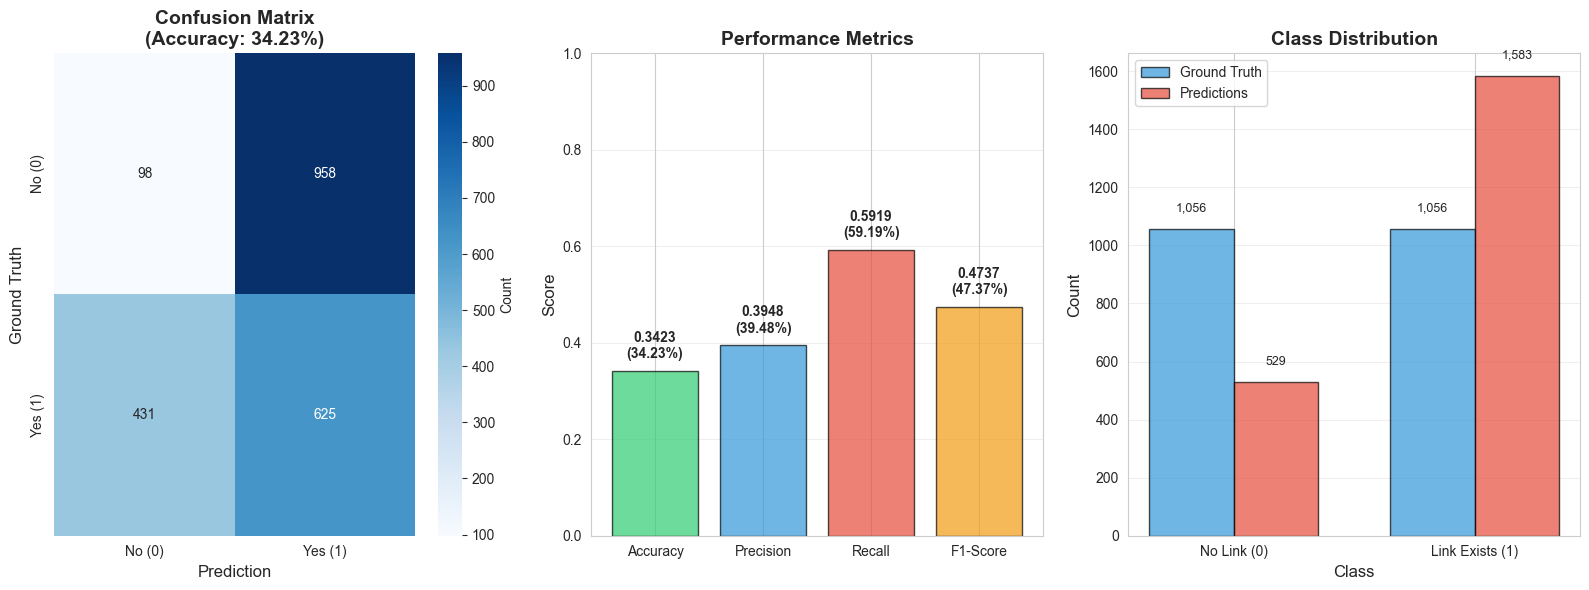

✓ Saved visualization: evaluation_metrics.png


In [62]:
# Create figure with subplots
fig = plt.figure(figsize=(16, 6))

# 1. Confusion Matrix Heatmap
ax1 = plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix\n(Accuracy: {accuracy*100:.2f}%)', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Prediction', fontsize=12)

# 2. Metrics Bar Chart
ax2 = plt.subplot(1, 3, 2)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Performance Metrics', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.4f}\n({value*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Class Distribution Comparison
ax3 = plt.subplot(1, 3, 3)
x = np.arange(2)
width = 0.35

true_counts = [(y_true_binary == 0).sum(), (y_true_binary == 1).sum()]
pred_counts = [(y_pred_binary == 0).sum(), (y_pred_binary == 1).sum()]

bars1 = plt.bar(x - width/2, true_counts, width, label='Ground Truth', 
                color='#3498db', alpha=0.7, edgecolor='black')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predictions', 
                color='#e74c3c', alpha=0.7, edgecolor='black')

plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(x, ['No Link (0)', 'Link Exists (1)'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height):,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(predictions_path.parent / 'evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization: evaluation_metrics.png")

## 6. Error Analysis

Analyze prediction errors to identify patterns.

In [ ]:
# Find errors
errors = []
for i, (true, pred) in enumerate(zip(y_true_binary, y_pred_binary)):
    if true != pred:
        errors.append({
            'index': i,
            'node_id': predictions[i]['node_id'],
            'true_label': 'yes' if true == 1 else 'no',
            'pred_label': 'yes' if pred == 1 else 'no',
            'error_type': 'False Positive' if (true == 0 and pred == 1) else 'False Negative',
            'prediction_text': predictions[i]['prediction']
        })

print("="*70)
print(" "*25 + "ERROR ANALYSIS")
print("="*70)

print(f"\n✓ Total Errors: {len(errors):,} / {len(y_pred):,} ({len(errors)/len(y_pred)*100:.2f}%)")

# Error breakdown
fp_count = sum(1 for e in errors if e['error_type'] == 'False Positive')
fn_count = sum(1 for e in errors if e['error_type'] == 'False Negative')

print(f"\n✓ Error Breakdown:")
print(f"  False Positives: {fp_count:,} ({fp_count/len(errors)*100:.2f}% of errors)")
print(f"    → Model predicted 'yes' but ground truth is 'no'")
print(f"  False Negatives: {fn_count:,} ({fn_count/len(errors)*100:.2f}% of errors)")
print(f"    → Model predicted 'no' but ground truth is 'yes'")

# Show error examples
print(f"\n✓ Example Errors (first 10):")
for i, error in enumerate(errors[:10]):
    print(f"\n  [{i+1}] {error['error_type']}")
    print(f"      Node ID: {error['node_id']}")
    print(f"      True: {error['true_label']} | Predicted: {error['pred_label']}")
    print(f"      Output: {error['prediction_text']}")

print("\n" + "="*70)

                         ERROR ANALYSIS

✓ Total Errors: 1,389 / 2,112 (65.77%)

✓ Error Breakdown:
  False Positives: 958 (68.97% of errors)
    → Model predicted 'yes' but ground truth is 'no'
  False Negatives: 431 (31.03% of errors)
    → Model predicted 'no' but ground truth is 'yes'

✓ Example Errors (first 10):

  [1] False Positive
      Node ID: 2650
      True: no | Predicted: yes
      Output: assistant

yes

  [2] False Negative
      Node ID: 1118
      True: yes | Predicted: no
      Output: assistant

no

  [3] False Positive
      Node ID: 1227
      True: no | Predicted: yes
      Output: assistant

yes

  [4] False Positive
      Node ID: 254
      True: no | Predicted: yes
      Output: assistant

yes

  [5] False Negative
      Node ID: 2676
      True: yes | Predicted: no
      Output: assistant

no

  [6] False Positive
      Node ID: 2427
      True: no | Predicted: yes
      Output: assistant

yes

  [7] False Negative
      Node ID: 379
      True: yes | Predic

## 7. Save Evaluation Results

Export metrics and error analysis to JSON.

In [64]:
# Compile results
evaluation_results = {
    "summary": {
        "total_samples": len(predictions),
        "valid_samples": len(y_pred),
        "invalid_samples": invalid_count,
        "total_errors": len(errors)
    },
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "auc_roc": float(auc_score) if auc_score is not None else None,
        "average_precision": float(avg_precision) if avg_precision is not None else None,
        "specificity": float(specificity),
        "sensitivity": float(sensitivity)
    },
    "confusion_matrix": {
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp)
    },
    "class_distribution": {
        "ground_truth": {
            "no_link": int((y_true_binary == 0).sum()),
            "link_exists": int((y_true_binary == 1).sum())
        },
        "predictions": {
            "no_link": int((y_pred_binary == 0).sum()),
            "link_exists": int((y_pred_binary == 1).sum())
        }
    },
    "errors": {
        "count": len(errors),
        "false_positives": fp_count,
        "false_negatives": fn_count,
        "examples": errors[:20]  # Save first 20 errors
    }
}

# Save results
results_path = predictions_path.parent / "evaluation_results.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print(f"✓ Saved evaluation results: {results_path.name}")
print(f"  Location: {results_path.parent}")

# Save errors to separate file for detailed analysis
errors_path = predictions_path.parent / "prediction_errors.json"
with open(errors_path, 'w', encoding='utf-8') as f:
    json.dump(errors, f, indent=2, ensure_ascii=False)

print(f"✓ Saved error analysis: {errors_path.name}")
print(f"  Total errors: {len(errors):,}")

✓ Saved evaluation results: evaluation_results.json
  Location: .
✓ Saved error analysis: prediction_errors.json
  Total errors: 1,389


## 8. Summary

Final summary of evaluation results.

In [65]:
print("="*70)
print(" "*20 + "EVALUATION COMPLETE!")
print("="*70)

print(f"\n📊 Model Performance Summary:")
print(f"  • Accuracy:  {accuracy*100:.2f}%")
print(f"  • Precision: {precision*100:.2f}%")
print(f"  • Recall:    {recall*100:.2f}%")
print(f"  • F1-Score:  {f1*100:.2f}%")

print(f"\n📈 Prediction Quality:")
print(f"  • Valid predictions: {len(y_pred):,} / {len(predictions):,} ({len(y_pred)/len(predictions)*100:.2f}%)")
print(f"  • Total errors: {len(errors):,} ({len(errors)/len(y_pred)*100:.2f}%)")
print(f"  • False Positives: {fp_count:,}")
print(f"  • False Negatives: {fn_count:,}")

print(f"\n💾 Saved Files:")
print(f"  • {results_path.name}")
print(f"  • {errors_path.name}")
print(f"  • evaluation_metrics.png")

print(f"\n🎯 Interpretation:")
if accuracy >= 0.90:
    print(f"  ✅ EXCELLENT: Model shows very strong link prediction performance!")
elif accuracy >= 0.80:
    print(f"  ✅ GOOD: Model performs well on link prediction task.")
elif accuracy >= 0.70:
    print(f"  ⚠️  MODERATE: Model shows reasonable performance, room for improvement.")
elif accuracy >= 0.60:
    print(f"  ⚠️  FAIR: Model performs better than random, but needs improvement.")
else:
    print(f"  ❌ POOR: Model performance is close to random (50% baseline).")

print("\n" + "="*70)

                    EVALUATION COMPLETE!

📊 Model Performance Summary:
  • Accuracy:  34.23%
  • Precision: 39.48%
  • Recall:    59.19%
  • F1-Score:  47.37%

📈 Prediction Quality:
  • Valid predictions: 2,112 / 2,112 (100.00%)
  • Total errors: 1,389 (65.77%)
  • False Positives: 958
  • False Negatives: 431

💾 Saved Files:
  • evaluation_results.json
  • prediction_errors.json
  • evaluation_metrics.png

🎯 Interpretation:
  ❌ POOR: Model performance is close to random (50% baseline).

